Bright soliton in 2D

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
L = 10.0
N = 256  
val = np.linspace(-L/2, L/2, N, endpoint=False)
x, y = np.meshgrid(val, val)
dx = val[1] - val[0]
k = 2 * np.pi * fftfreq(N, d=dx)

kx_1d = 2 * np.pi * fftfreq(N, d=dx)
kx, ky = np.meshgrid(kx_1d, kx_1d)
k_sq = kx**2 + ky**2

dt = 0.001 
T_final = 1.6
steps_per_frame = 10 
total_frames = int(T_final / (dt * steps_per_frame))


kappa1 = -2.0  # stable
kappa2 = -25.0   # unstable

In [3]:
psi = np.exp(-(x**2 + y**2) / 4).astype(complex)
norm = np.sqrt(np.sum(np.abs(psi)**2) * dx**2)
psi /= norm 
psi_init = psi.copy()

In [4]:
times1, densities1, energies1 = [], [], []

def get_stats(p, k_vec, dx_val, kappa):
    dens = np.sum(np.abs(p)**2) * dx_val
    p_hat = fft2(p)
    d_psi = ifft2(1j * k_vec * p_hat)
    ener = np.sum(0.5 * np.abs(d_psi)**2 + 0.5 * kappa * np.abs(p)**4) * dx_val
    return dens, ener

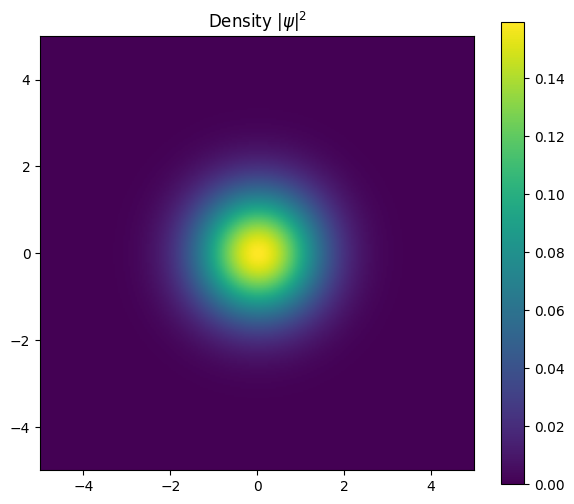

In [5]:
fig1, ax1 = plt.subplots(figsize=(7, 6))
im1 = ax1.imshow(np.abs(psi)**2, extent=[-L/2, L/2, -L/2, L/2], 
               cmap='viridis', vmin=0, vmax=np.max(np.abs(psi)**2))
time_text = ax1.text(0.05, 0.92, '', transform=ax1.transAxes, color='white', 
                     fontsize=12, fontweight='bold')
ax1.set_title(fr"Density $|\psi|^2$")
fig1.colorbar(im1, ax=ax1)

In [6]:
def update(frame):
    global psi
    for _ in range(steps_per_frame):
        # TSSP
        psi *= np.exp(-0.5j * kappa1 * np.abs(psi)**2 * dt)

        psi_hat = fft2(psi)
        psi_hat *= np.exp(-0.5j * k_sq * dt)
        psi = ifft2(psi_hat)
        
        psi *= np.exp(-0.5j * kappa1 * np.abs(psi)**2 * dt)
        
    d, e = get_stats(psi, k, dx, kappa1)
    densities1.append(d)
    energies1.append(e)
    times1.append(frame * dt * steps_per_frame)   
    
    im1.set_data(np.abs(psi)**2)
    time_text.set_text(f"Time: {frame * dt * steps_per_frame:.3f}")
    return [im1]

ani = FuncAnimation(fig1, update, frames=total_frames, interval=30, blit=True)

ani.save("bright_solitons_2d/bs2d1.html", writer='html')
plt.close()

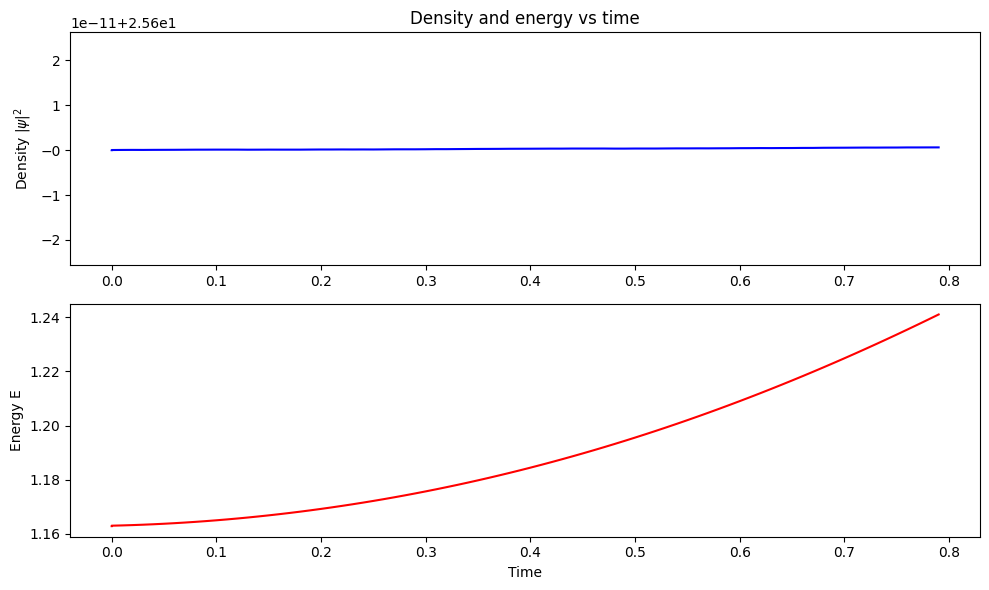

In [7]:
fig_stats, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.set_title("Density and energy vs time")
ax1.plot(times1, densities1, 'b'); ax1.set_ylabel(r"Density $|\psi|^2$")
ax2.plot(times1, energies1, 'r'); ax2.set_ylabel("Energy E")
ax2.set_xlabel("Time")
plt.tight_layout()
plt.savefig("bright_solitons_2d/te_bs2d1.pdf")
plt.show()

In [ ]:
dt = 0.001 
T_final = 0.8
steps_per_frame = 10 
total_frames = int(T_final / (dt * steps_per_frame))
times2, densities2, energies2 = [], [], []
psi = np.exp(-(x**2 + y**2) / 4).astype(complex)
norm = np.sqrt(np.sum(np.abs(psi)**2) * dx**2)
psi /= norm 
psi_init = psi.copy()

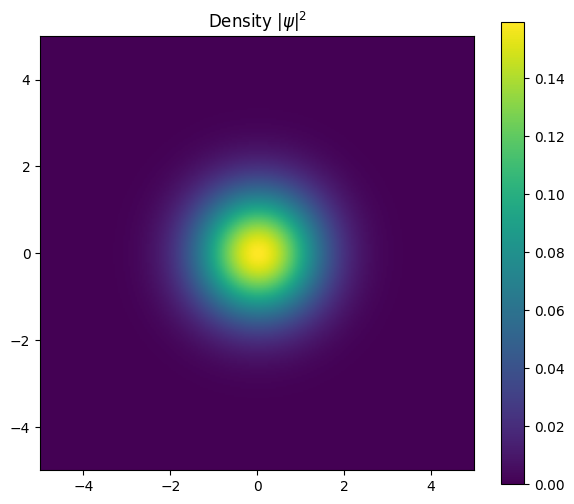

In [9]:
fig2, ax2 = plt.subplots(figsize=(7, 6))
im2 = ax2.imshow(np.abs(psi)**2, extent=[-L/2, L/2, -L/2, L/2], 
               cmap='viridis', vmin=0, vmax=np.max(np.abs(psi)**2))
time_text = ax2.text(0.05, 0.92, '', transform=ax2.transAxes, color='white', 
                     fontsize=12, fontweight='bold')
ax2.set_title(fr"Density $|\psi|^2$")
fig2.colorbar(im2, ax=ax2)

In [10]:
def update(frame):
    global psi
    for _ in range(steps_per_frame):
        # TSSP
        psi *= np.exp(-0.5j * kappa2 * np.abs(psi)**2 * dt)

        psi_hat = fft2(psi)
        psi_hat *= np.exp(-0.5j * k_sq * dt)
        psi = ifft2(psi_hat)
        
        psi *= np.exp(-0.5j * kappa2 * np.abs(psi)**2 * dt)
        
    d, e = get_stats(psi, k, dx, kappa2)
    densities2.append(d)
    energies2.append(e)
    times2.append(frame * dt * steps_per_frame)   
    
    im2.set_data(np.abs(psi)**2)
    time_text.set_text(f"Time: {frame * dt * steps_per_frame:.3f}")
    return [im2]

ani = FuncAnimation(fig2, update, frames=total_frames, interval=30, blit=True)


ani.save("bright_solitons_2d/bs2d2.html", writer='html')

plt.close()

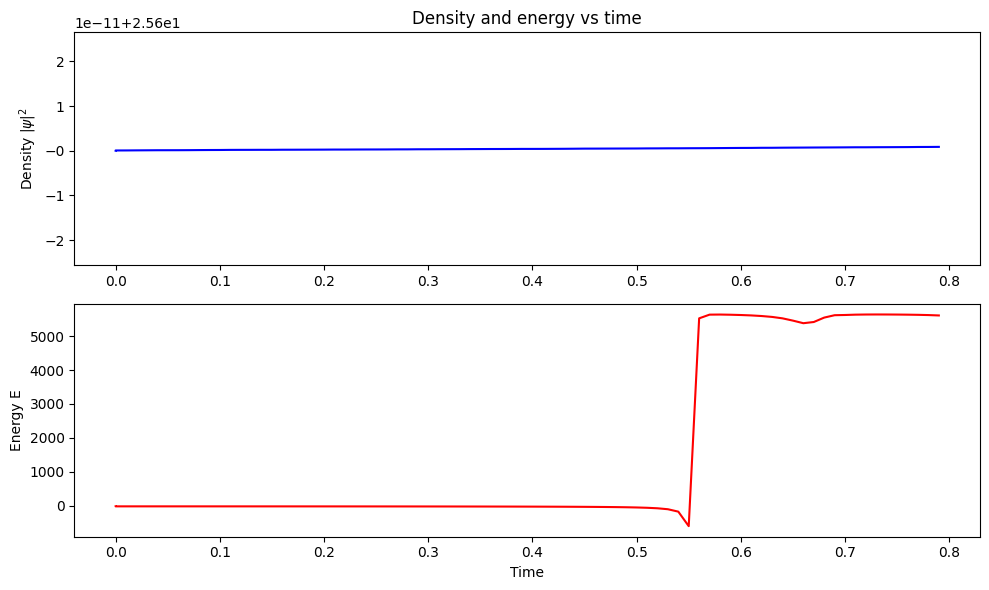

In [11]:
fig_stats, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.set_title("Density and energy vs time")
ax1.plot(times2, densities2, 'b'); ax1.set_ylabel(r"Density $|\psi|^2$")
ax2.plot(times2, energies2, 'r'); ax2.set_ylabel("Energy E")
ax2.set_xlabel("Time")
plt.tight_layout()
plt.savefig("bright_solitons_2d/te_bs2d2.pdf")
plt.show()